In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix,RocCurveDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.shape

(32581, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
df["person_emp_length"].fillna(df["person_emp_length"].median(), inplace=True)

df["loan_int_rate"].fillna(df["loan_int_rate"].median(), inplace=True)

C:\Users\aksha\AppData\Local\Temp\ipykernel_2668\343834966.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["person_emp_length"].fillna(df["person_emp_length"].median(), inplace=True)
C:\Users\aksha\AppData\Local\Temp\ipykernel_2668\343834966.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series 

0        16.02
1        11.14
2        12.87
3        15.23
4        14.27
         ...  
32576    13.16
32577     7.49
32578    10.99
32579    11.48
32580     9.99
Name: loan_int_rate, Length: 32581, dtype: float64

In [9]:
df.duplicated().sum()

np.int64(165)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
# income after taking loan burden
df["income_to_loan"] = df["person_income"] / df["loan_amnt"]

In [12]:
df["employment_category"] = np.where(df["person_emp_length"]>=5,"Experienced","New")

In [14]:
df.sample(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_to_loan,employment_category
24743,32,75000,MORTGAGE,0.0,EDUCATION,B,10000,11.89,0,0.13,N,5,7.500000,New
26786,27,113000,MORTGAGE,5.0,DEBTCONSOLIDATION,A,6425,6.03,0,0.06,N,7,17.587549,Experienced
7377,23,92000,RENT,0.0,PERSONAL,A,6500,8.00,0,0.07,N,2,14.153846,New
31762,48,140000,MORTGAGE,4.0,EDUCATION,B,18000,9.99,0,0.13,N,11,7.777778,New
17992,31,201996,MORTGAGE,11.0,EDUCATION,C,20000,NaN,0,0.10,N,10,10.099800,Experienced


In [15]:
X = df.drop("loan_status",axis=1)
y = df["loan_status"]

In [16]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

C:\Users\aksha\AppData\Local\Temp\ipykernel_2668\2723785854.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns


In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32416 non-null  int64  
 1   person_income               32416 non-null  int64  
 2   person_home_ownership       32416 non-null  str    
 3   person_emp_length           31529 non-null  float64
 4   loan_intent                 32416 non-null  str    
 5   loan_grade                  32416 non-null  str    
 6   loan_amnt                   32416 non-null  int64  
 7   loan_int_rate               29321 non-null  float64
 8   loan_status                 32416 non-null  int64  
 9   loan_percent_income         32416 non-null  float64
 10  cb_person_default_on_file   32416 non-null  str    
 11  cb_person_cred_hist_length  32416 non-null  int64  
 12  income_to_loan              32416 non-null  float64
 13  employment_category         32416 non-null  str

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline = Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])

categorical_pipeline = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore"))])

In [19]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([("num",numeric_pipeline,num_cols),("cat",categorical_pipeline,cat_cols)])

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [21]:
# Logistic Regression
model=Pipeline([("preprocessor",preprocessor),("classifier",LogisticRegression(max_iter=1000))])
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [22]:
y_pred=model.predict(X_test)
y_prob=model.predict_proba(X_test)[:,1]

In [24]:
print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision :",precision_score(y_test,y_pred))
print("Recall :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))
print("ROC AUC :",roc_auc_score(y_test,y_prob))

Accuracy : 0.8689080814312153
Precision : 0.7699619771863118
Recall : 0.5712270803949224
F1 Score : 0.6558704453441295
ROC AUC : 0.8678838485726075


In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5066
           1       0.77      0.57      0.66      1418

    accuracy                           0.87      6484
   macro avg       0.83      0.76      0.79      6484
weighted avg       0.86      0.87      0.86      6484



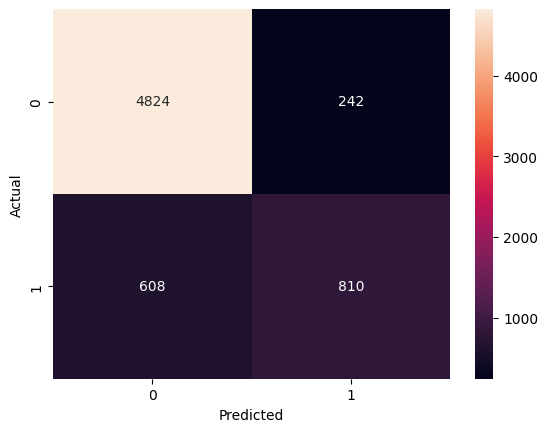

In [36]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

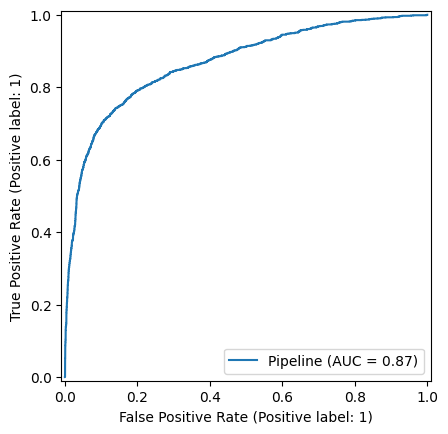

In [29]:
RocCurveDisplay.from_estimator(model,X_test,y_test)
plt.show()

In [30]:
# Decision tree
model2 = Pipeline([("preprocessor",preprocessor),("classifier",DecisionTreeClassifier(random_state=42))])
model2.fit(X_train,y_train)
tree_pred = model2.predict(X_test)
tree_prob = model2.predict_proba(X_test)[:,1]

print("Accuracy :",accuracy_score(y_test,tree_pred))
print("ROC AUC :",roc_auc_score(y_test,tree_prob))

Accuracy : 0.8903454657618753
ROC AUC : 0.8475587686821683


In [31]:
# Random Forest
rf_model = Pipeline([("preprocessor",preprocessor),("classifier",RandomForestClassifier(n_estimators=200,random_state=42))])
rf_model.fit(X_train,y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("Accuracy :",accuracy_score(y_test,rf_pred))
print("Precision :",precision_score(y_test,rf_pred))
print("Recall :",recall_score(y_test,rf_pred))
print("F1 Score :",f1_score(y_test,rf_pred))
print("ROC AUC :",roc_auc_score(y_test,rf_prob))

Accuracy : 0.9344540407156077
Precision : 0.9706161137440759
Recall : 0.7221438645980254
F1 Score : 0.8281439547108774
ROC AUC : 0.9288142638469802


In [39]:
import joblib
joblib.dump(rf_model, "model.pkl", compress=9)
model = joblib.load("model.pkl")

In [34]:
sample = X.iloc[[0]]
prediction = model.predict(sample)
print(prediction)

[1]


In [35]:
import joblib
import pandas as pd

# Load model
model = joblib.load("model.pkl")

sample = pd.DataFrame({
    "person_age":[30],
    "person_income":[85000],
    "person_home_ownership":["MORTGAGE"],
    "person_emp_length":[8],
    "loan_intent":["EDUCATION"],
    "loan_grade":["A"],
    "loan_amnt":[8000],
    "loan_int_rate":[7.5],
    "loan_percent_income":[0.09],
    "cb_person_default_on_file":["N"],
    "cb_person_cred_hist_length":[9],
    "income_to_loan":[85000/8000],
    "employment_category":["Experienced"]
})

prediction = model.predict(sample)

if prediction[0] == 0:
    print("Good Credit Risk ✅")
else:
    print("Bad Credit Risk ❌")

Good Credit Risk ✅


In [37]:
import sklearn
import scipy

print(np.__version__)
print(pd.__version__)
print(sklearn.__version__)
print(scipy.__version__)

2.4.4
3.0.2
1.8.0
1.16.3


In [38]:
import joblib
print(joblib.__version__)

1.5.3
